In [1]:
import numpy as np
import pandas as pd
import uproot
from pathlib import Path
from scipy.interpolate import RegularGridInterpolator

import matplotlib.pyplot as plt
from mutools.plotting import use_style
from mutools.plotting.helpers import mark_axis
from mutools.plotting import run
import mutools.plotting as mp

use_style('rootlike')

REPO = Path('/Users/mueller/Projects/spineosc')

In [2]:
WHICH = 'exclusive'

SELECTIONS = {
    'inclusive': (REPO / 'resolution_inclusive_v1_PROplot_histograms.root', [None]),
    'exclusive': (REPO / 'resolution_exclusive_v1_PROplot_histograms.root', ['Single-Proton', 'Multi-Proton']),
}

BIAS_VARIABLES = {
    4: r'$(E^{reco}_{vis} - E^{true}_{vis}) / E^{true}_{vis}$',
    5: r'$(E^{reco}_{vis} - E^{true}_{\nu}) / E^{true}_{\nu}$',
    6: r'$(E^{reco}_{CCQE} - E^{true}_{vis}) / E^{true}_{vis}$',
    7: r'$(E^{reco}_{CCQE} - E^{true}_{\nu}) / E^{true}_{\nu}$',
    8: r'$(T^{reco}_{\mu} - T^{true}_{\mu}) / T^{true}_{\mu}$',
    9: r'$(T^{reco}_{p} - T^{true}_{p}) / T^{true}_{p}$',
    # Reco vs reco: no truth involved, so this one is computable in data too.
    10: r'$(E^{reco}_{CCQE} - E^{reco}_{vis}) / E^{reco}_{vis}$',
}

# mutools pairs the FIRST label with the LAST subchannel in the file (see
# construct_proxy_stack), so this list runs opposite to the XML's declaration
# order of intime, cos, nc, nuecc, othercc, target. Colors stay in XML order.
SUBCHANNELS = [r'Target $\nu_\mu$ CC', r'Other $\nu_\mu$ CC', r'$\nu_e$ CC', r'$\nu$ NC',
               'Out-of-time Cosmics', 'In-time Cosmics']
SUBCHANNEL_COLORS = ['C0', 'C1', 'C2', 'C4', 'C3', 'C5']

# Biases built on the CCQE estimator, which assumes a single-proton final
# state; they are dropped from the multi-proton channel.
CCQE_VARIABLES = {6, 7, 10}

# Target POT from the XML's <detector> blocks (these are MC-only configs).
DETECTORS = ['SBND', 'ICARUS Run 2', 'ICARUS Run 4']
POT = ['1.00e20 POT', '2.00e20 POT', '3.00e20 POT']

# Vertical headroom over the tallest bin, so the legend clears the stack.
HEADROOM = 1.5

# Set to a directory to write PDFs instead of only displaying them.
SAVE_TO = None


/Users/mueller/Projects/mutools/src/mutools/plotting/profit.py:764: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  figure = plt.figure(figsize=(8, 6))


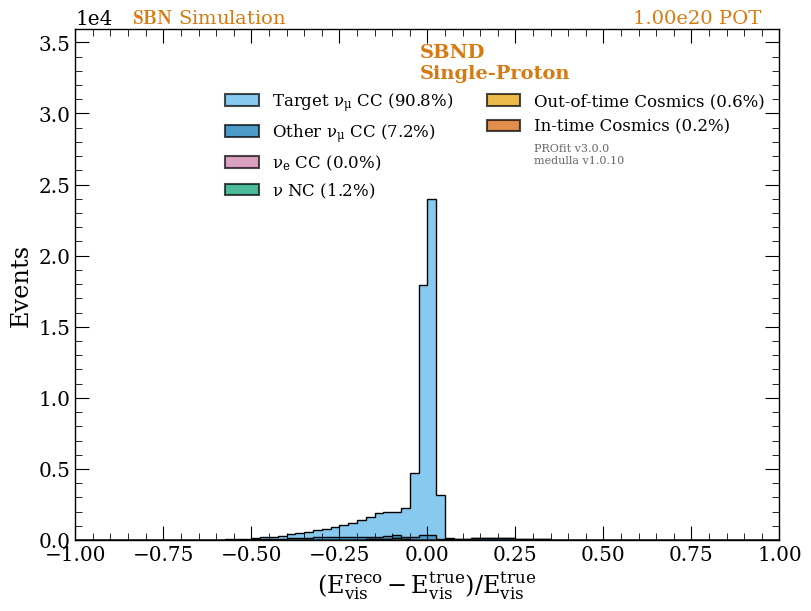

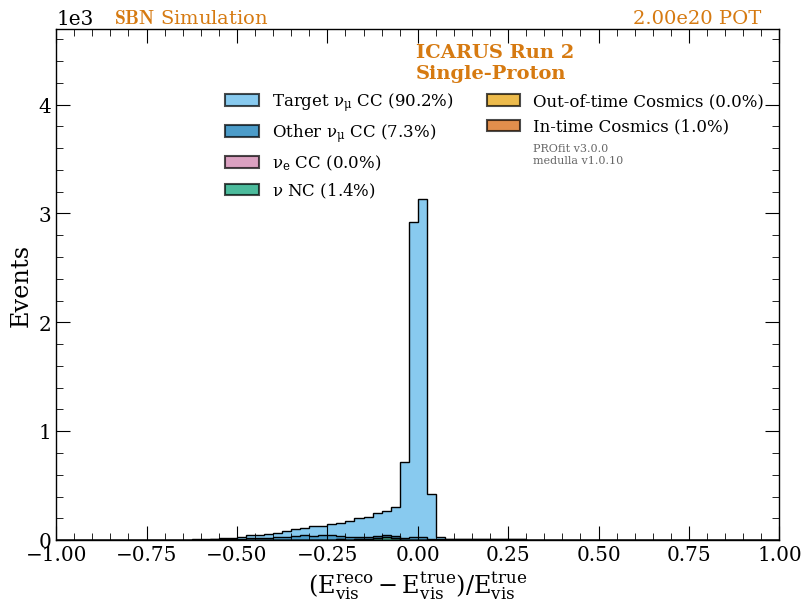

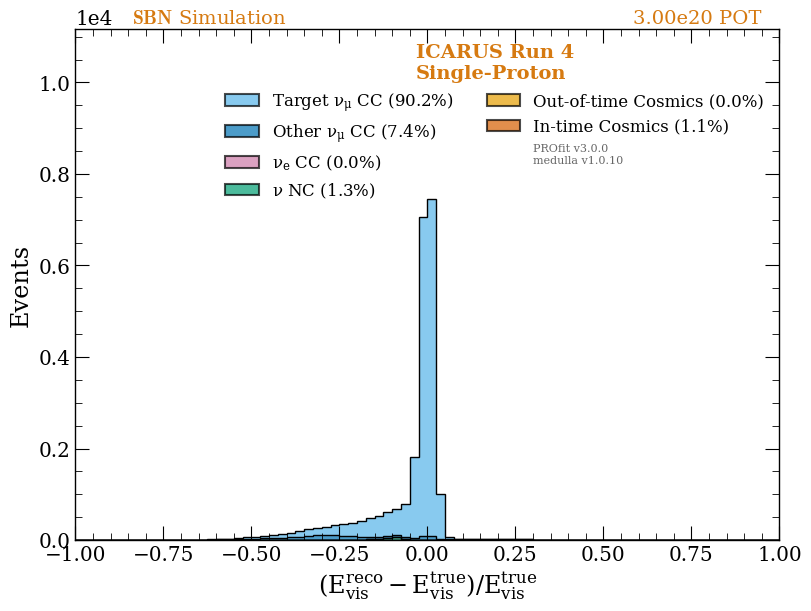

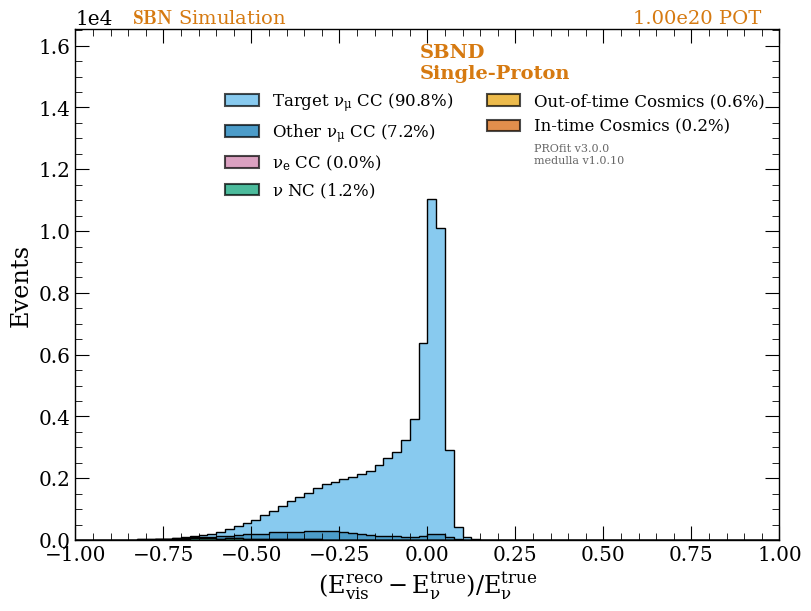

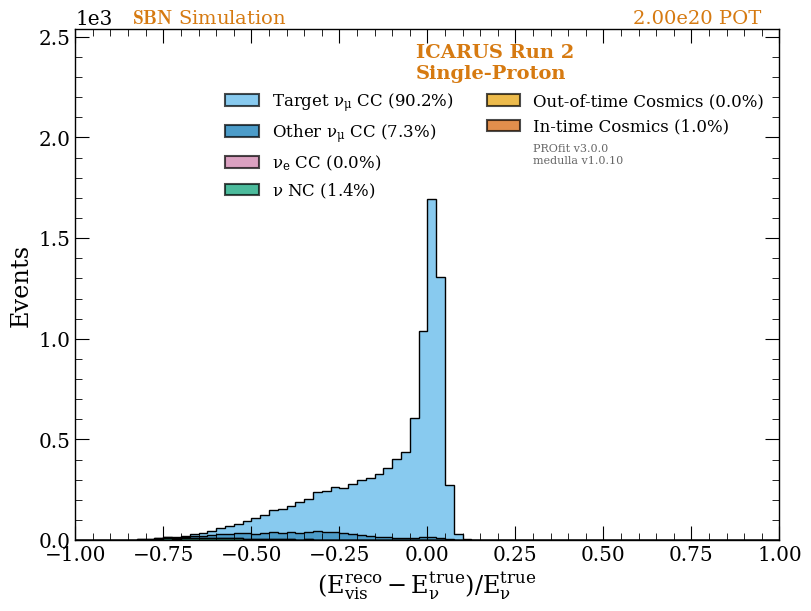

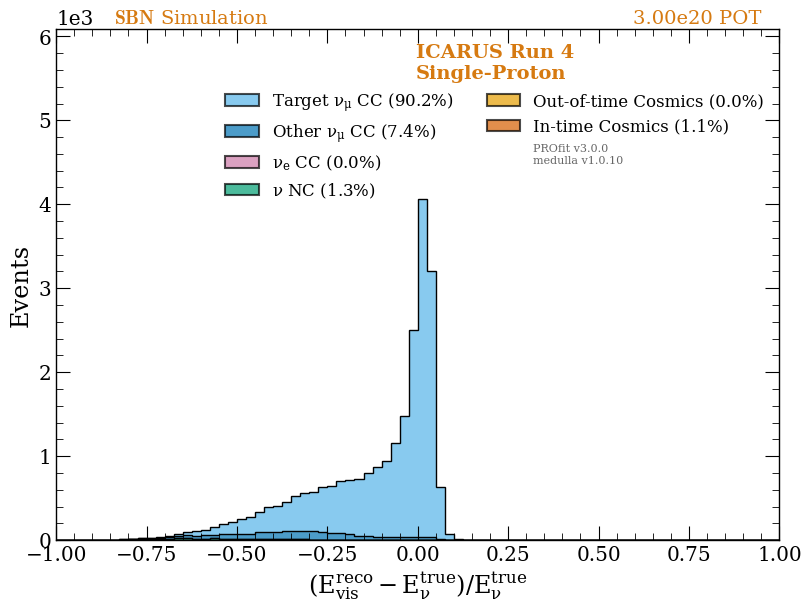

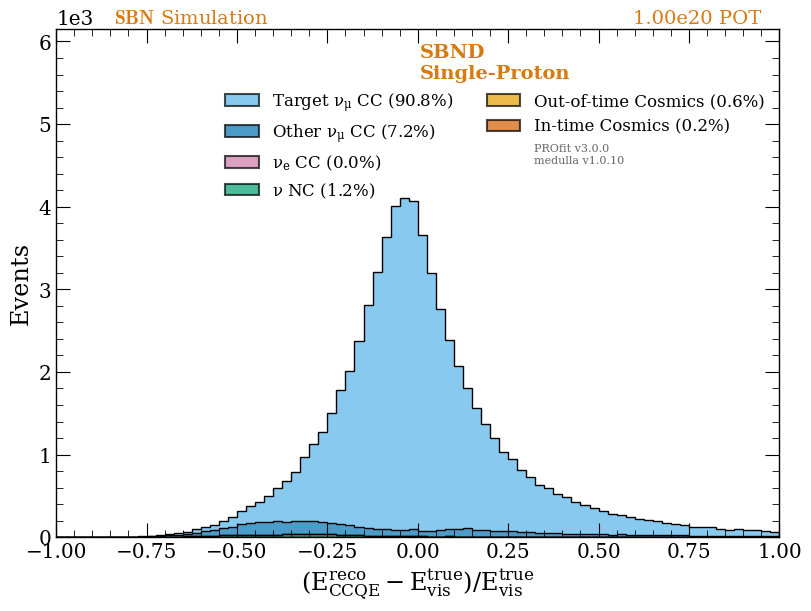

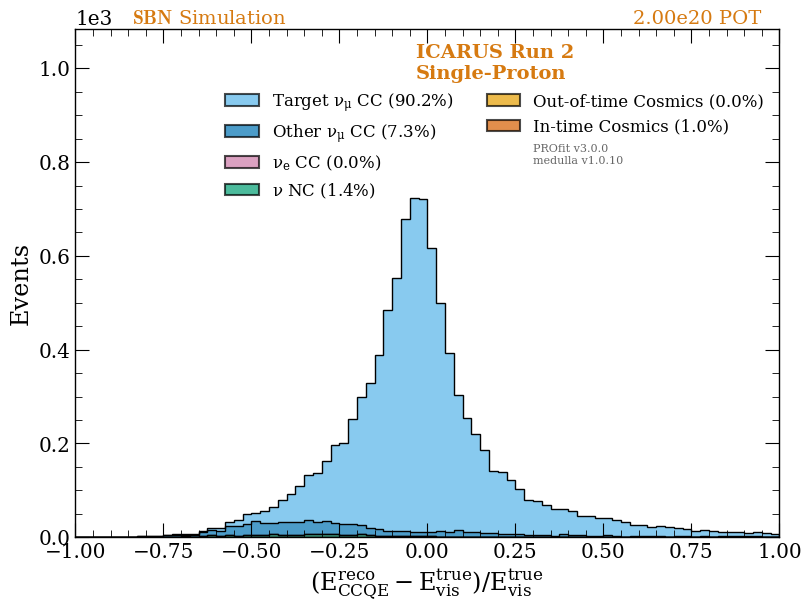

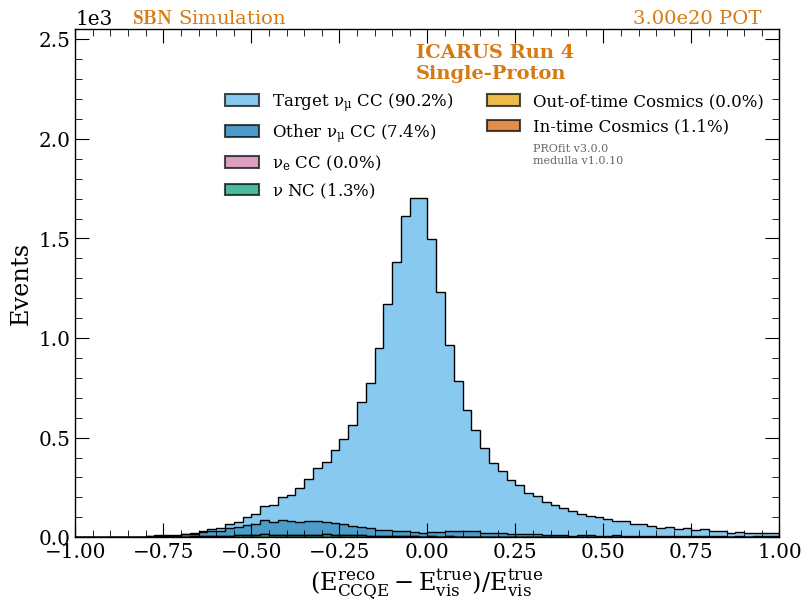

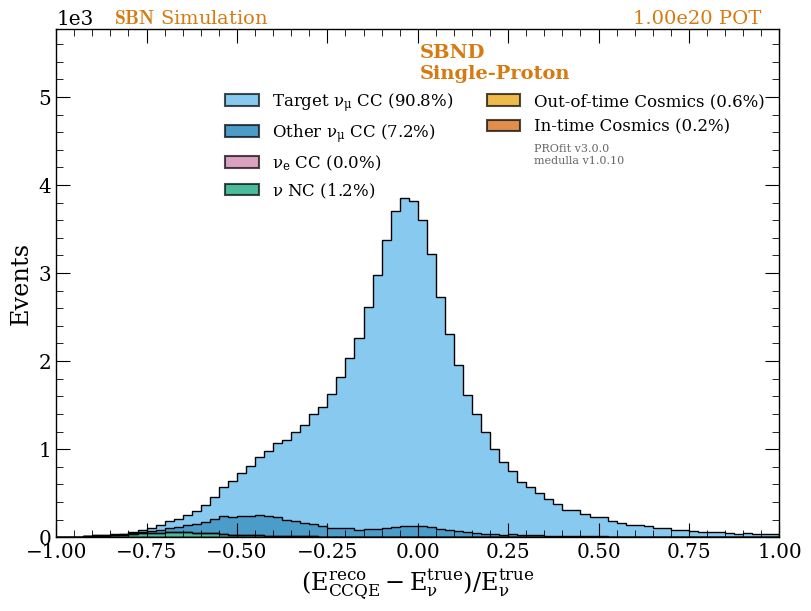

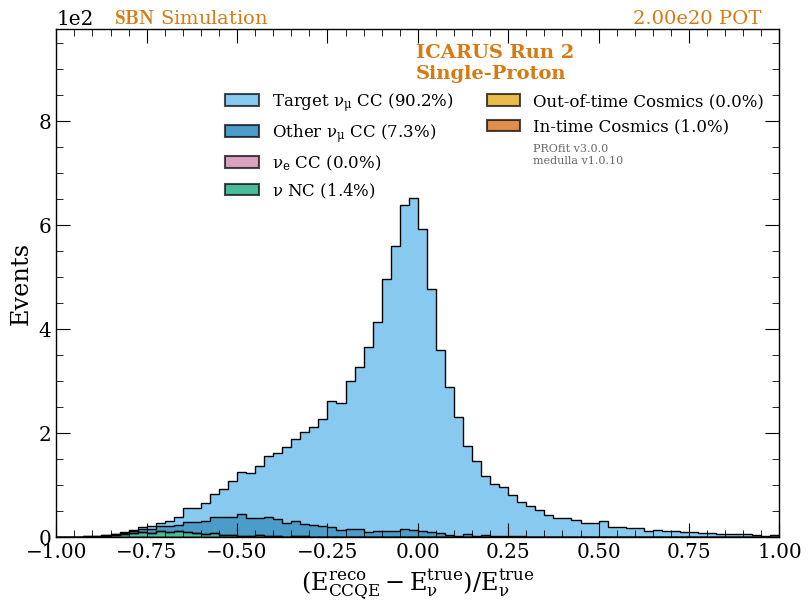

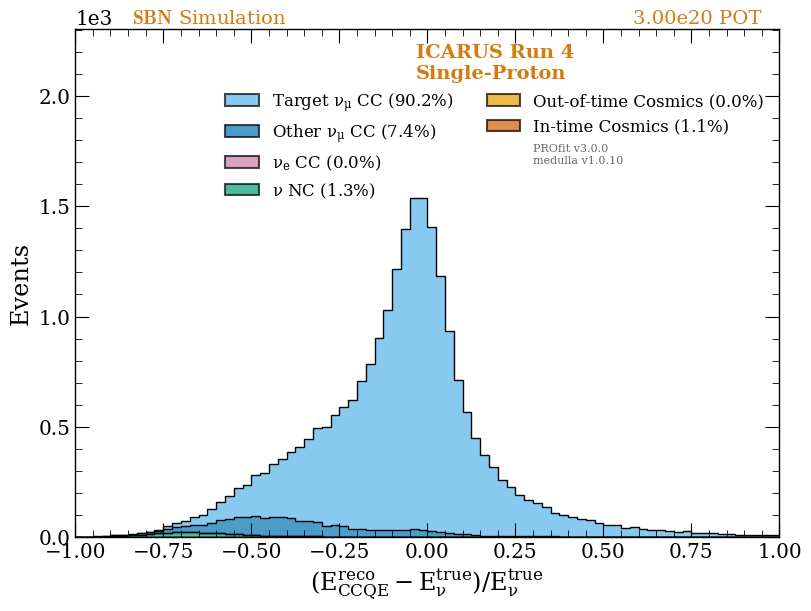

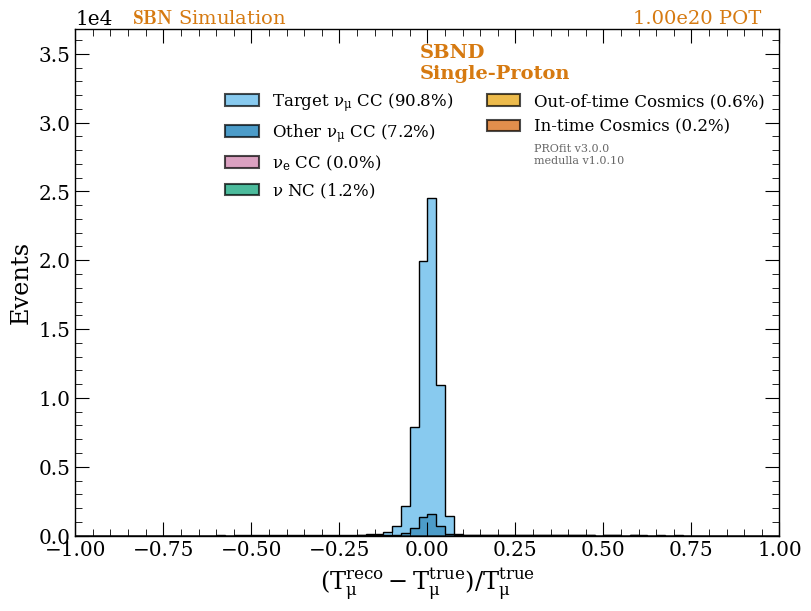

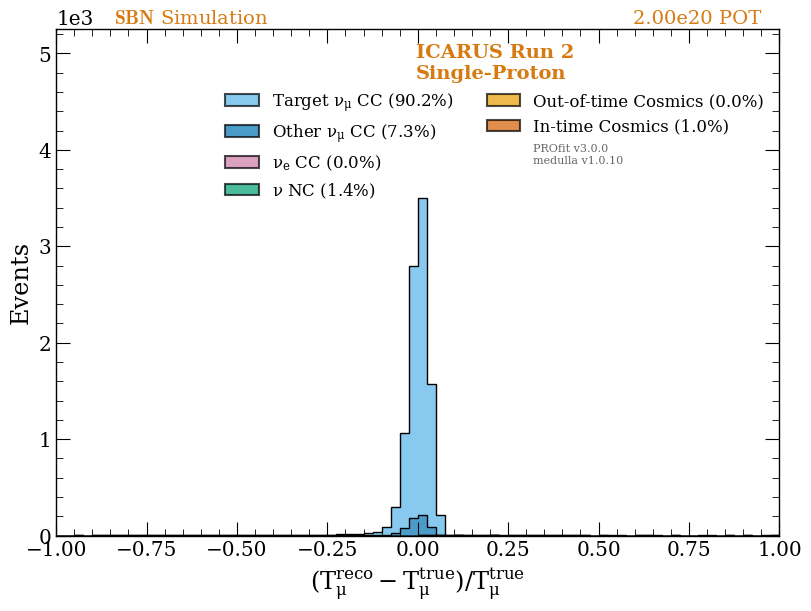

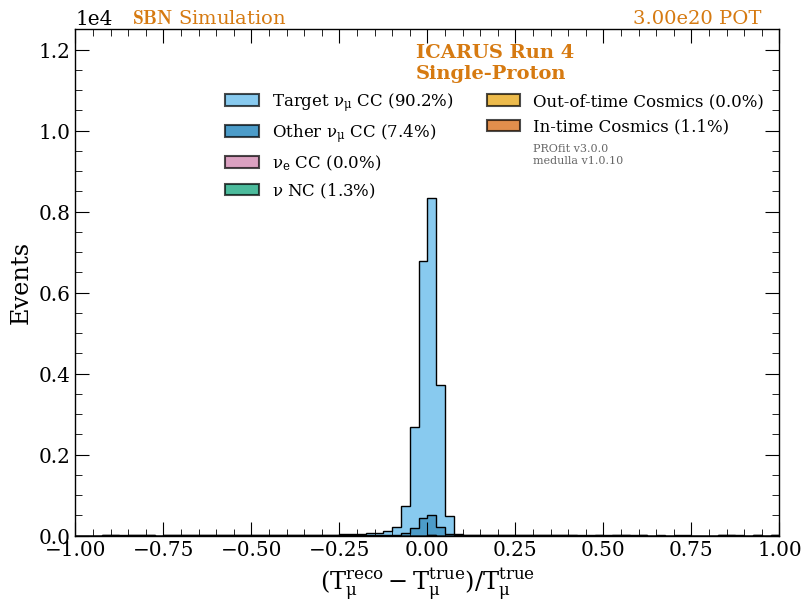

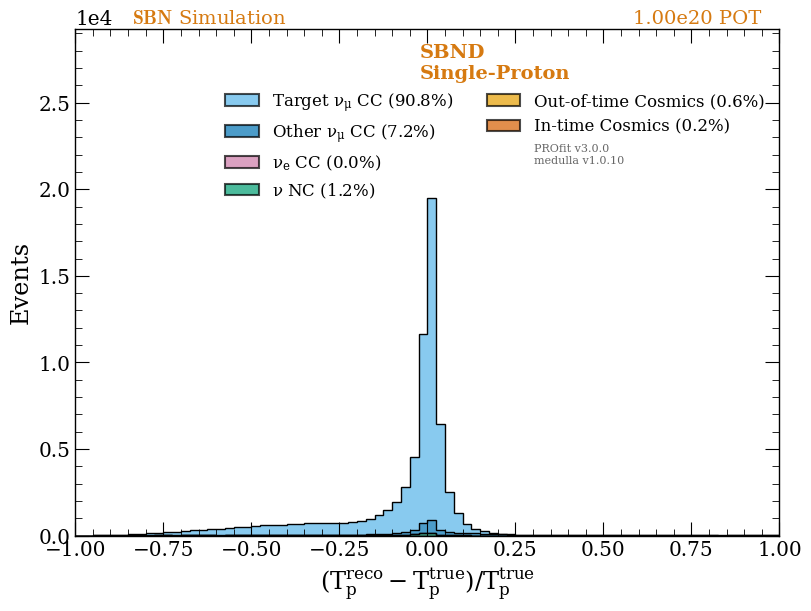

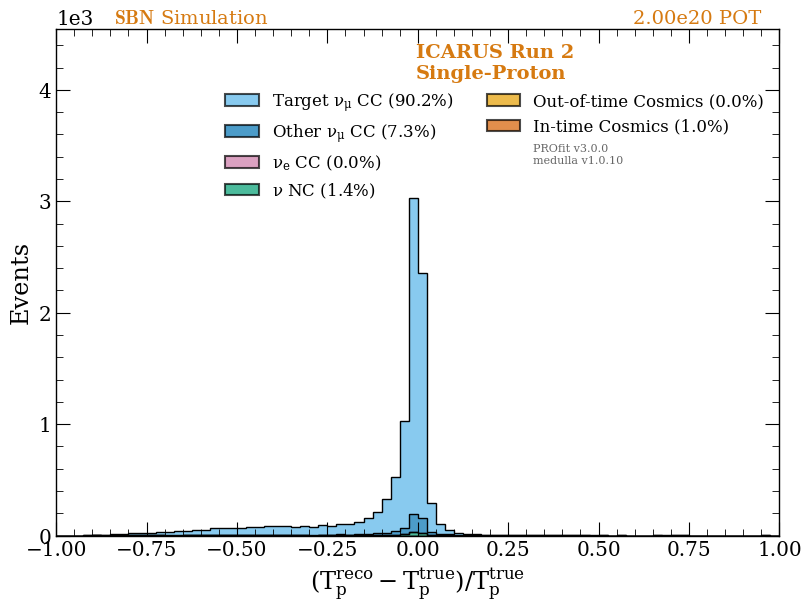

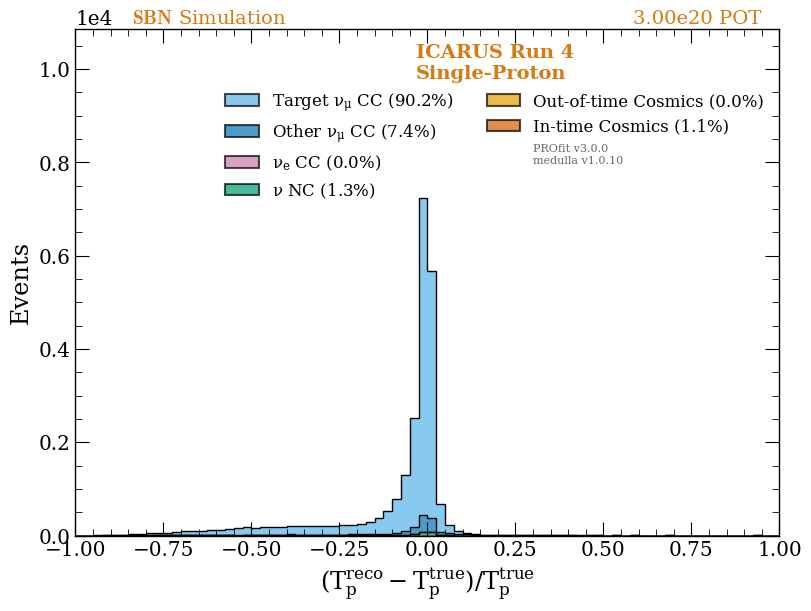

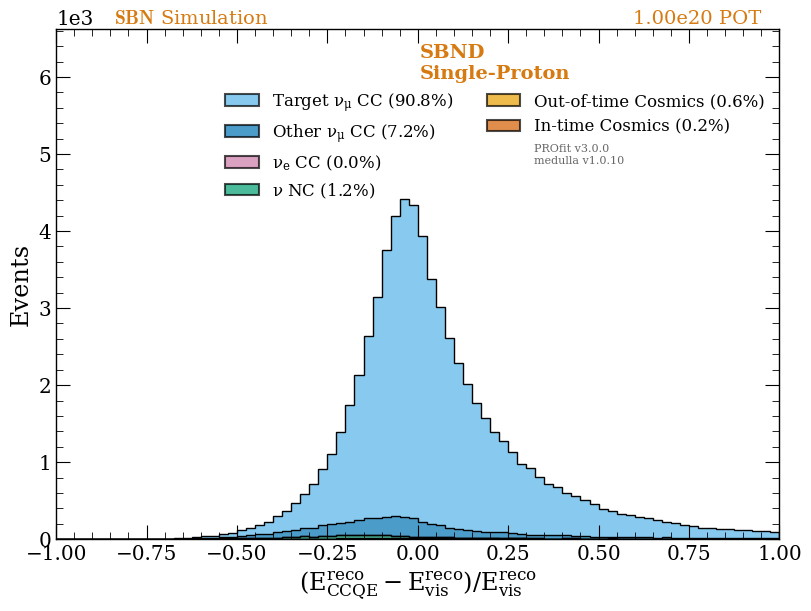

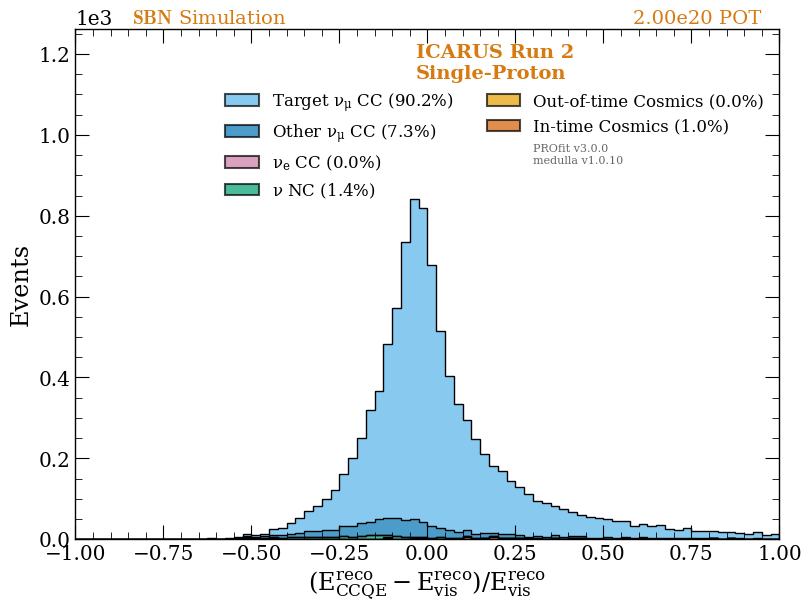

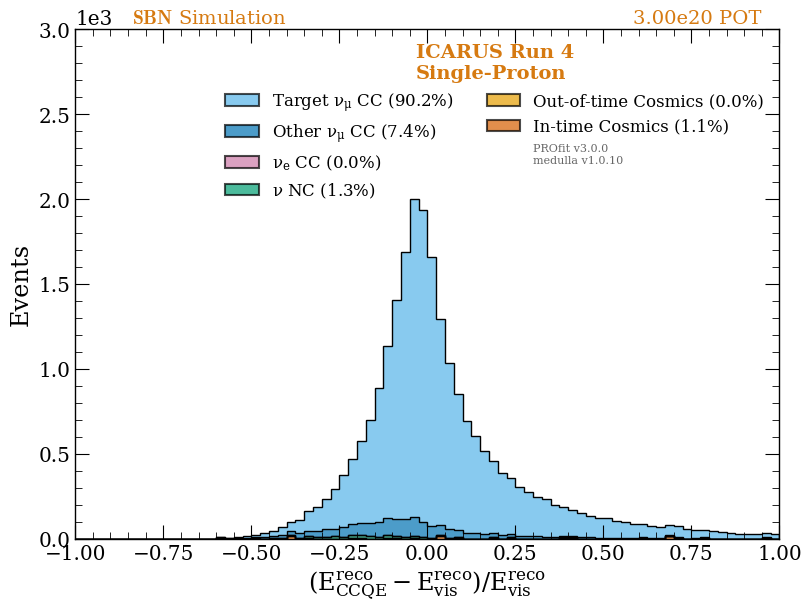

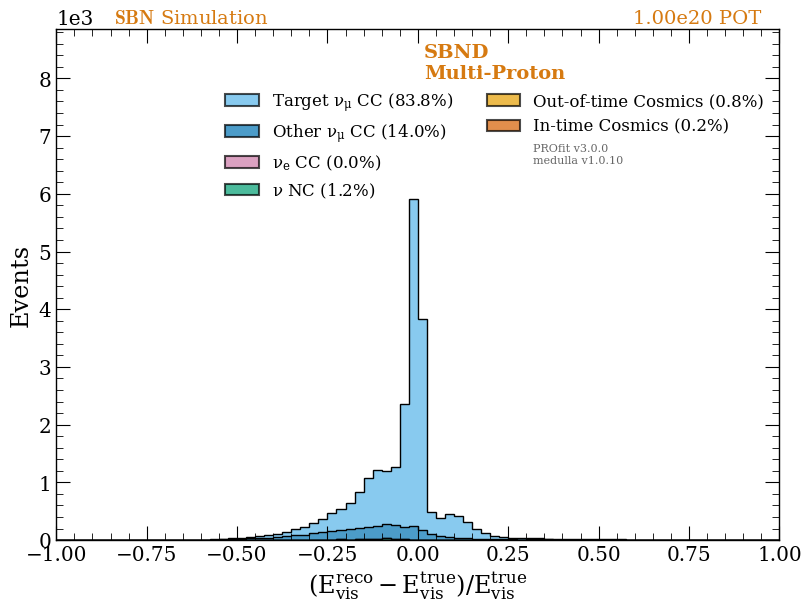

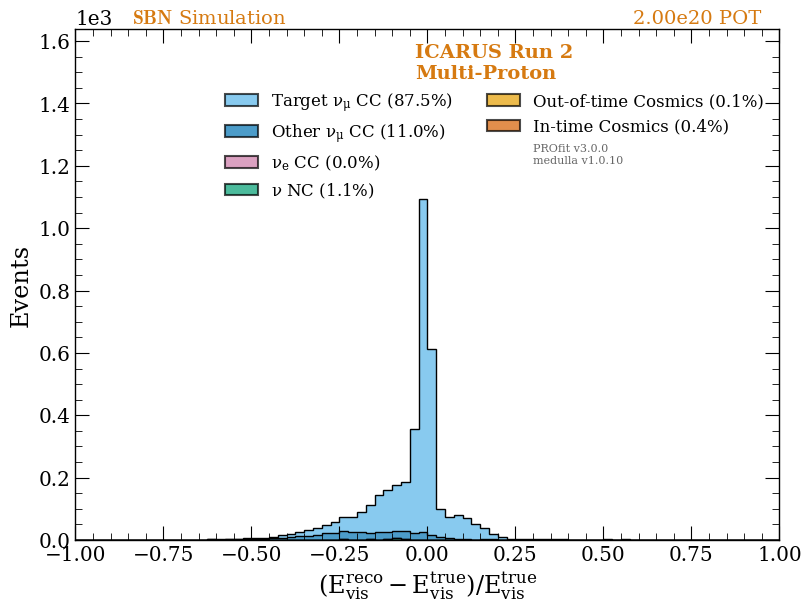

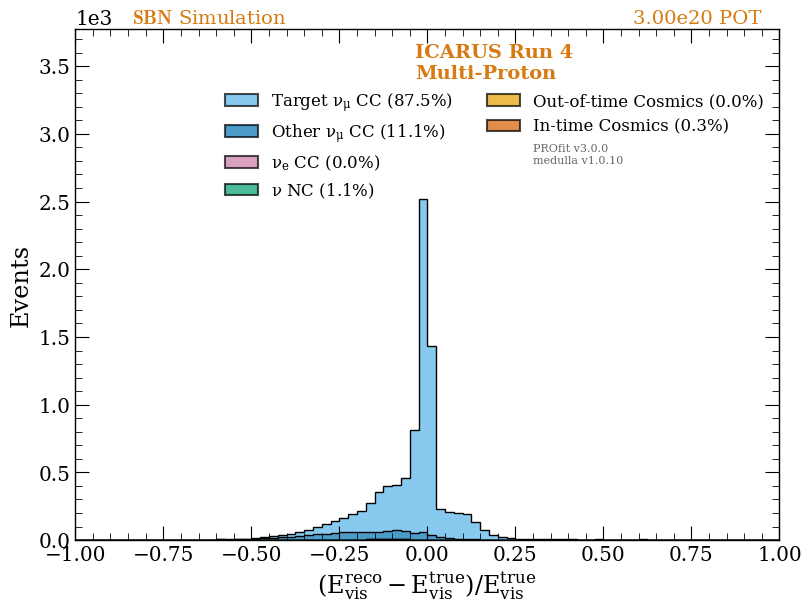

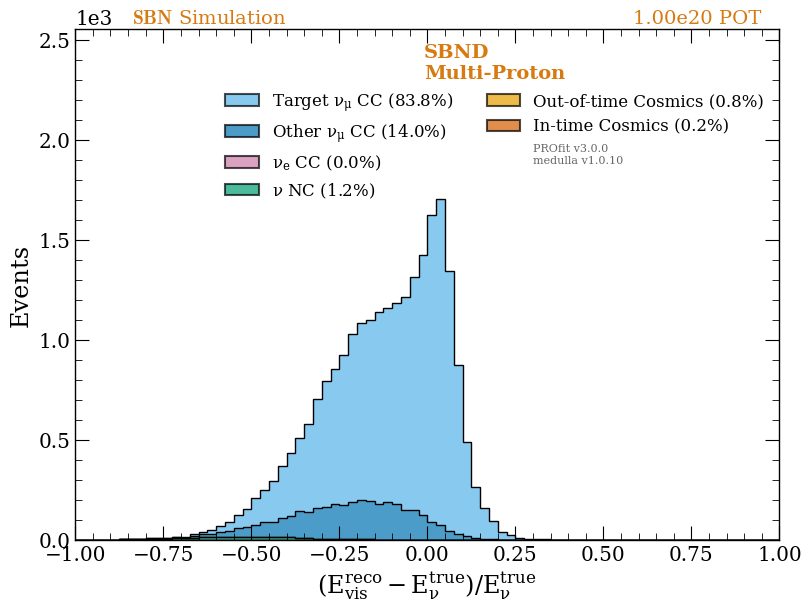

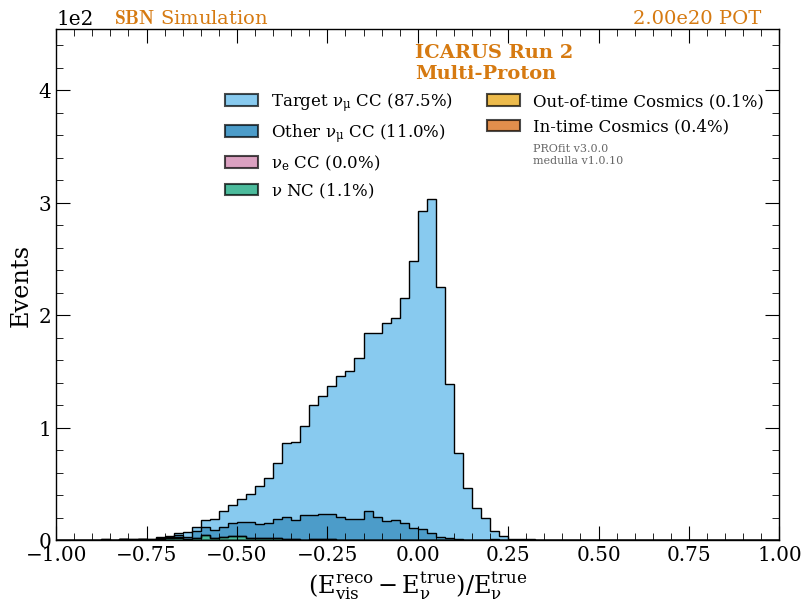

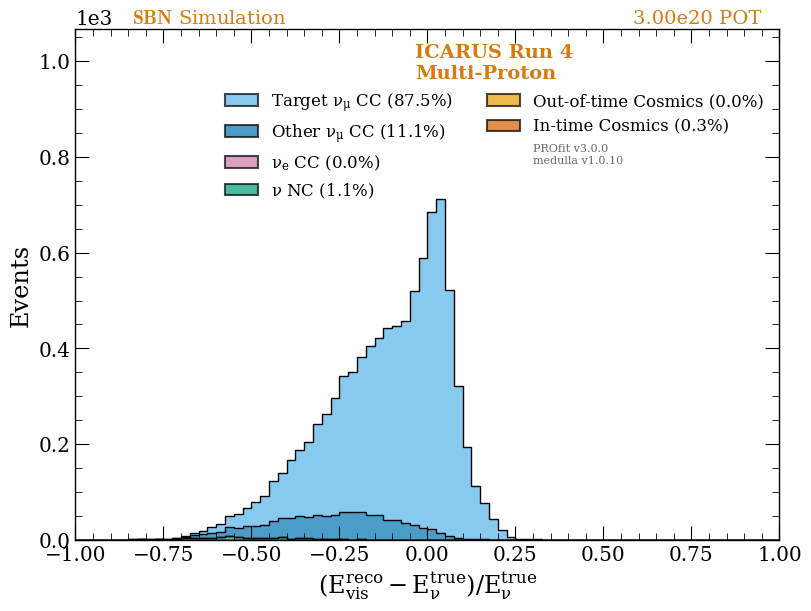

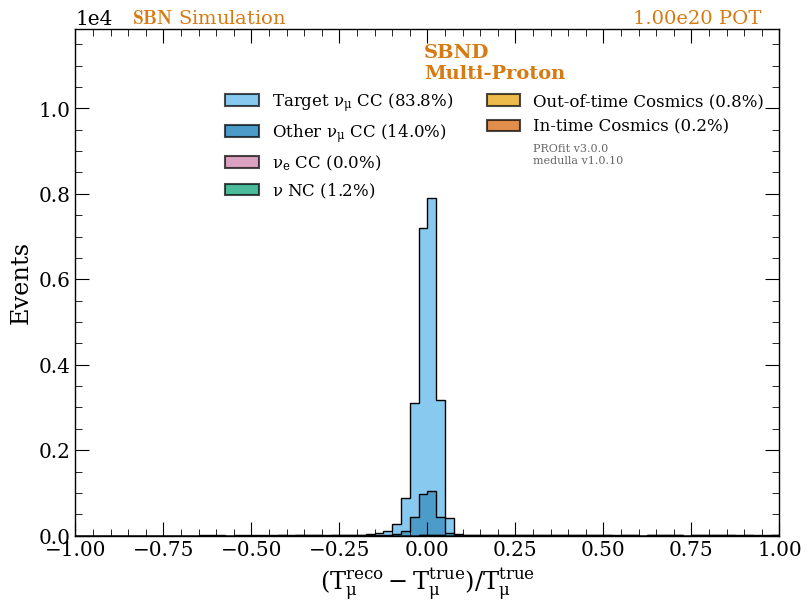

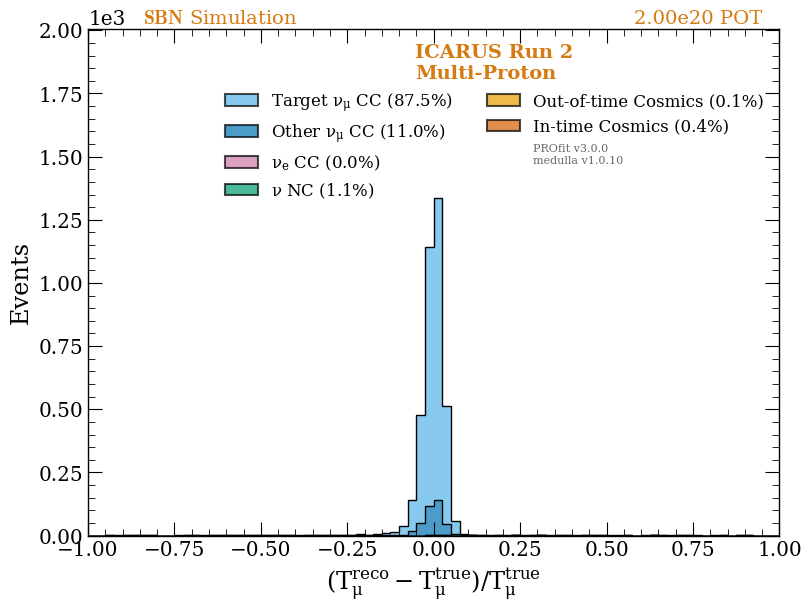

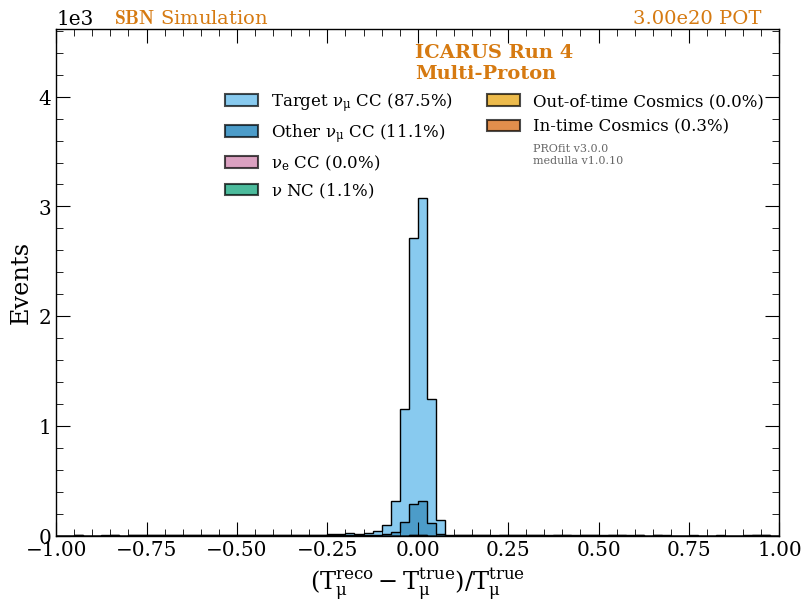

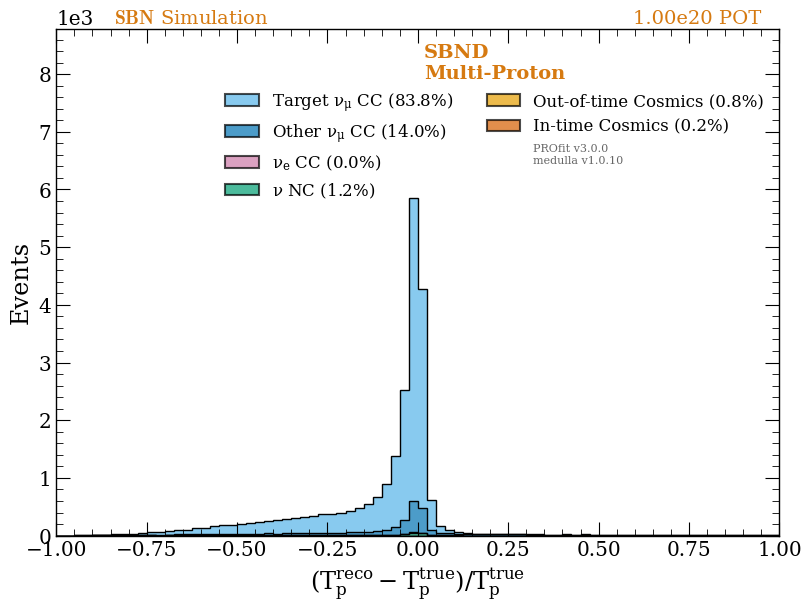

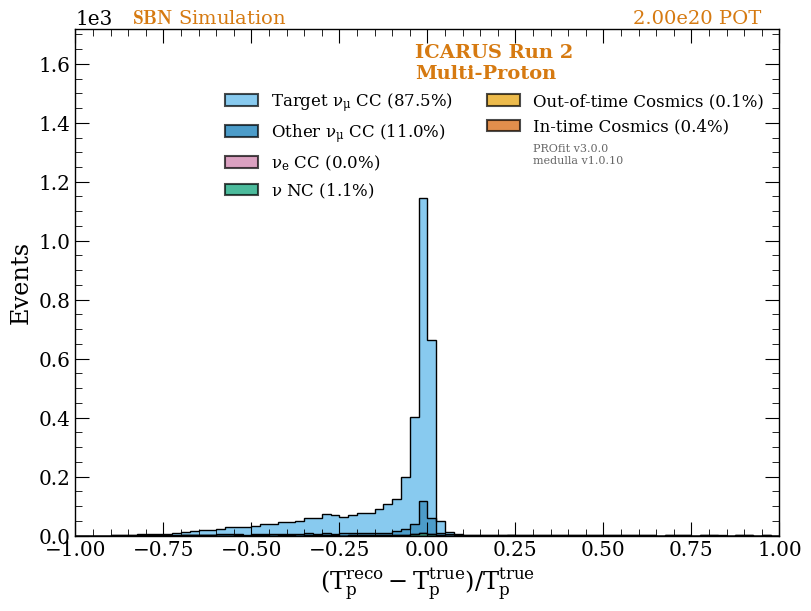

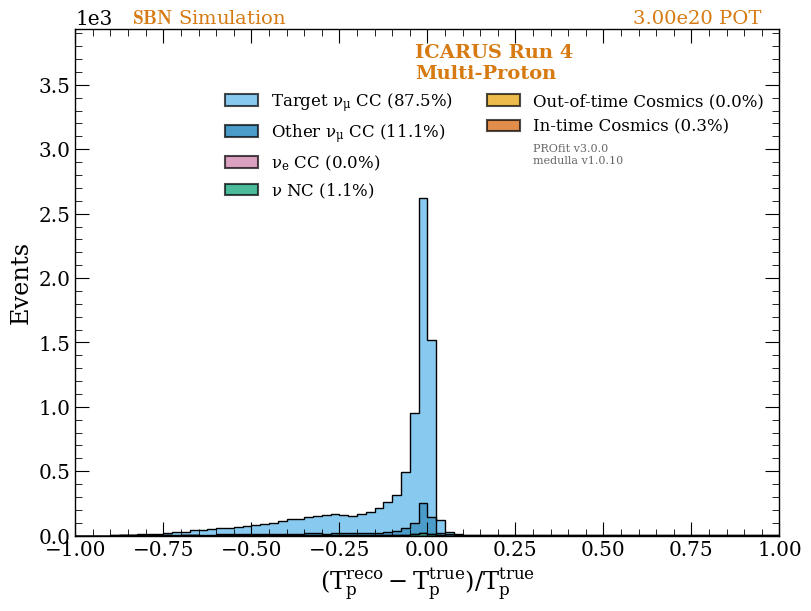

In [3]:
from mutools.plotting.profit import ProfitPlotData, TraceType

input_file, channel_labels = SELECTIONS[WHICH]
mp.saver.configure(mark_hadj=0.055)

# Read the stored histograms once to size each y-axis.
contents = ProfitPlotData(input_file)


def variables_for(channel):
    """Variables to plot for one channel. The CCQE estimator assumes a
    single-proton final state, so its biases are meaningless in multi-proton."""
    if channel_labels[channel] == 'Multi-Proton':
        return [v for v in BIAS_VARIABLES if v not in CCQE_VARIABLES]
    return list(BIAS_VARIABLES)


def headroom_ylim(variable, detector, channel):
    trace = contents.get_trace(f'{variable}:0:{detector}:{channel}:total:CV', TraceType.HIST_CONTENTS)
    return [0.0, float(HEADROOM * trace[:, 3].max())]

for channel, channel_label in enumerate(channel_labels):
    for variable in variables_for(channel):
        xlabel = BIAS_VARIABLES[variable]
        for detector, detector_label in enumerate(DETECTORS):
            run({
                'general': {
                    'input': str(input_file),
                    'output': str(Path(SAVE_TO) / WHICH / f'ch{channel}') if SAVE_TO else '',
                    'savefig': SAVE_TO is not None,
                    'code_version': 'v3.0.0',
                    'selection_version': 'v1.0.10',
                    'subchannels': SUBCHANNELS,
                    'detectors': DETECTORS,
                    'channels': channel_labels,
                    'counter_index': 3,  # the Count variable
                },
                'plot': [{
                    'type': 'histogram',
                    'variable': variable,
                    'channel': channel,
                    'detectors': [detector],
                    'colors': SUBCHANNEL_COLORS,
                    'xlabel': xlabel,
                    'ylabel': 'Events',
                    'xlim': [-1.0, 1.0],
                    'ylim': headroom_ylim(variable, detector, channel),
                    'disable_systematics': True,
                    'counter_fmt': '.1%',
                    'watermark': r'$\bf{SBN}$ Simulation',
                    'right_watermark': POT[detector],
                    'legend_ncol': 2,
                    'legend_loc': 'upper right',
                }],
            })


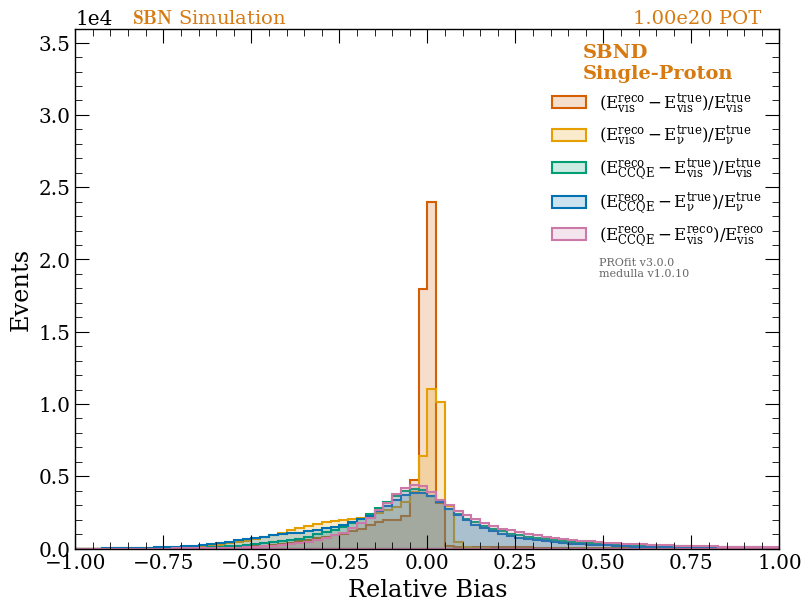

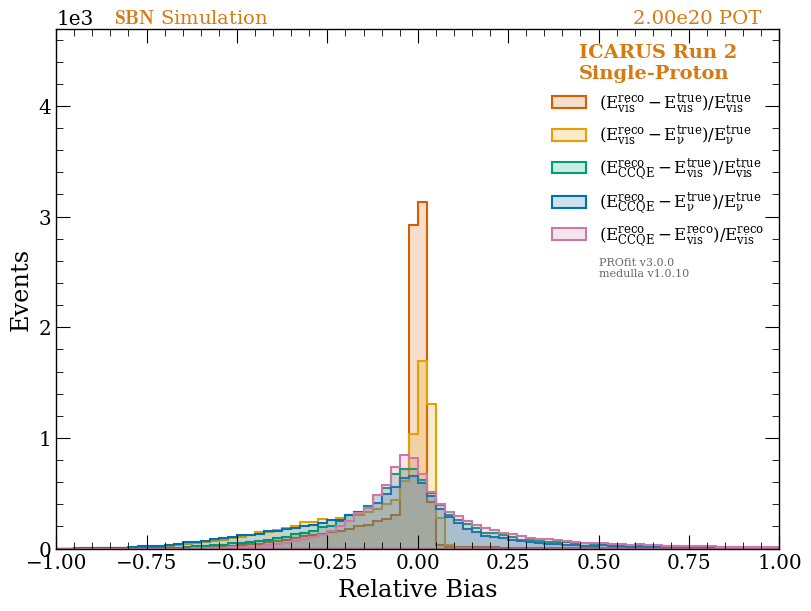

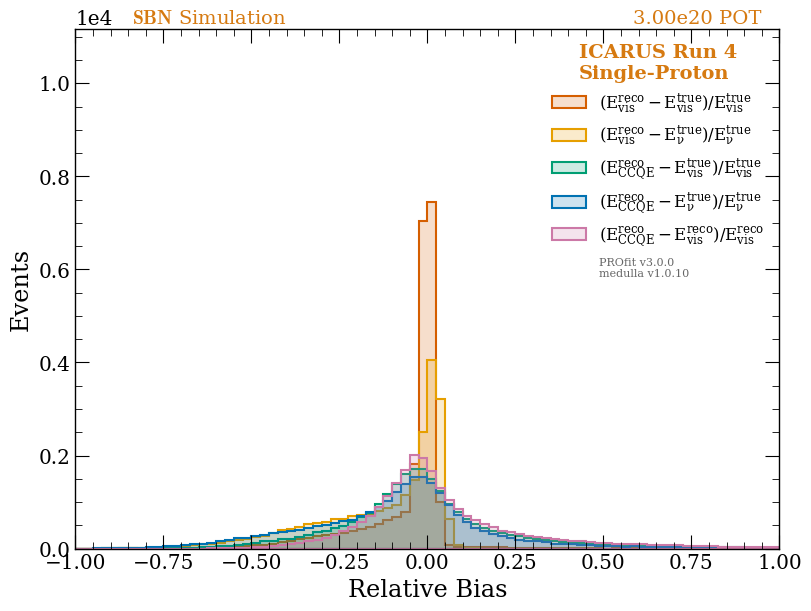

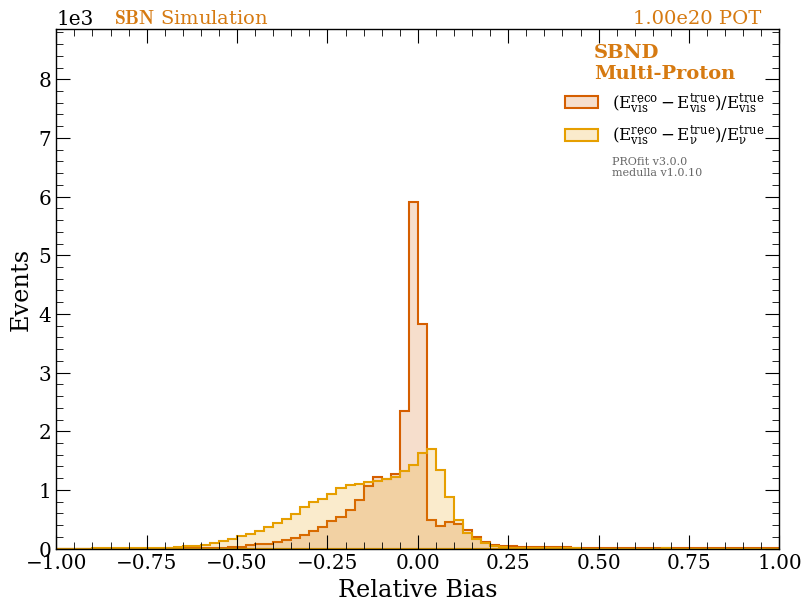

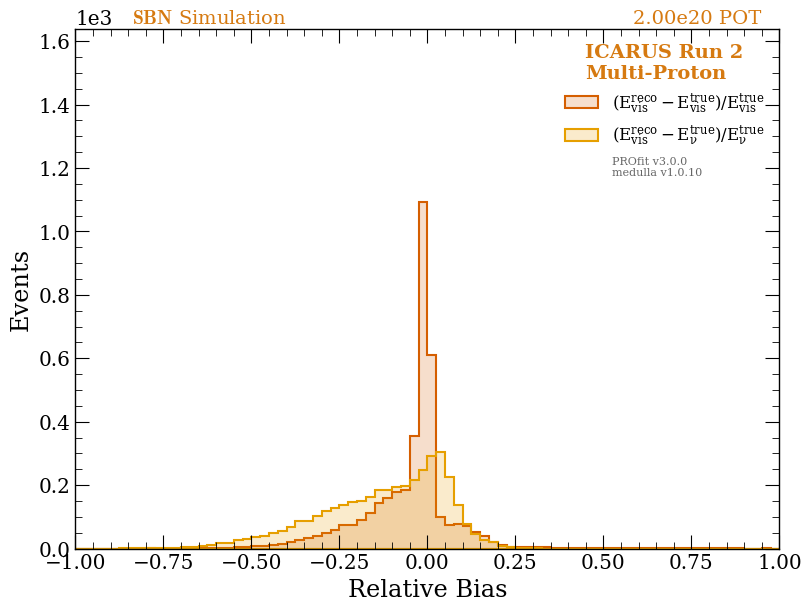

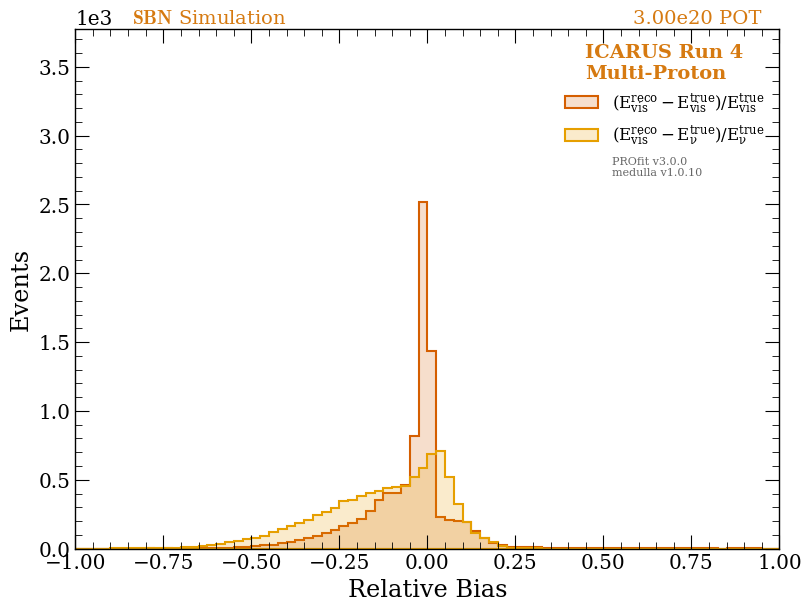

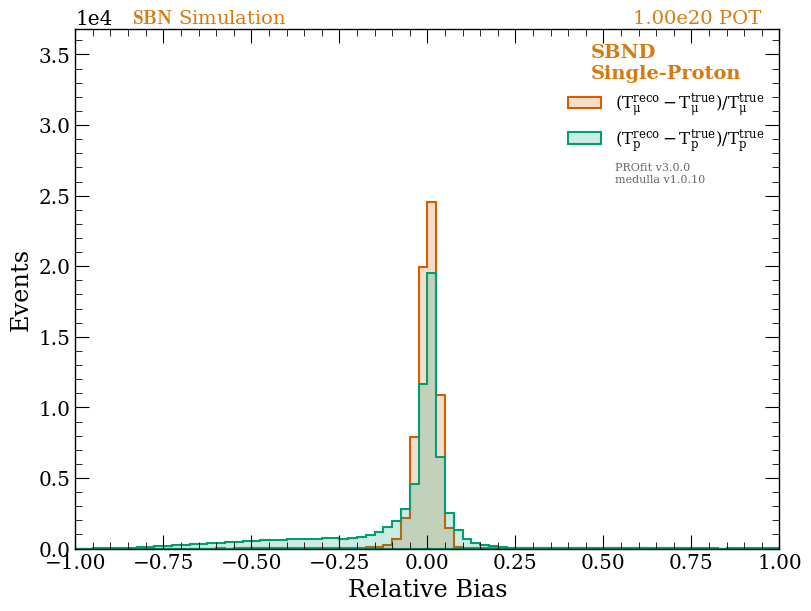

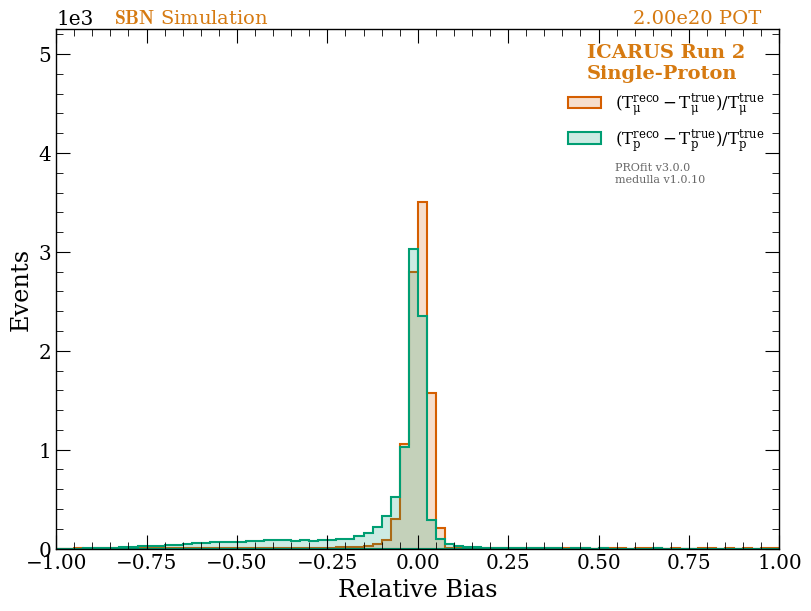

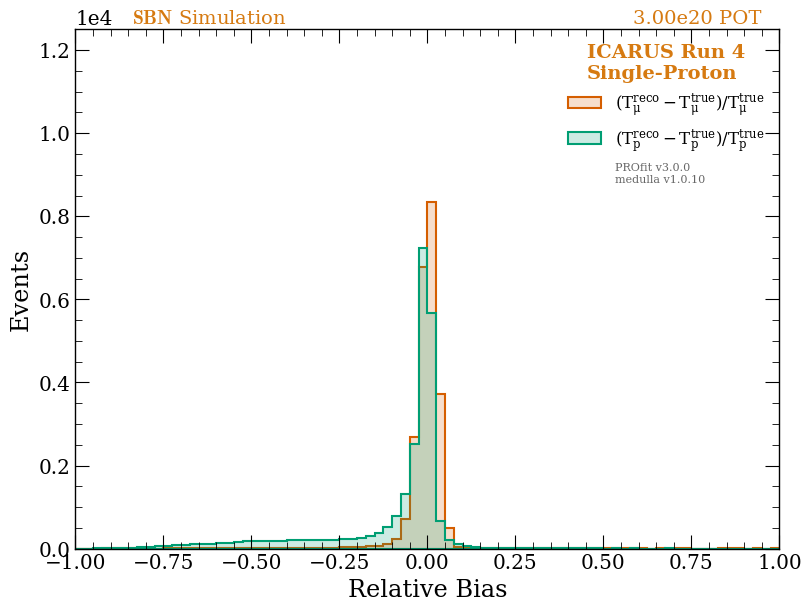

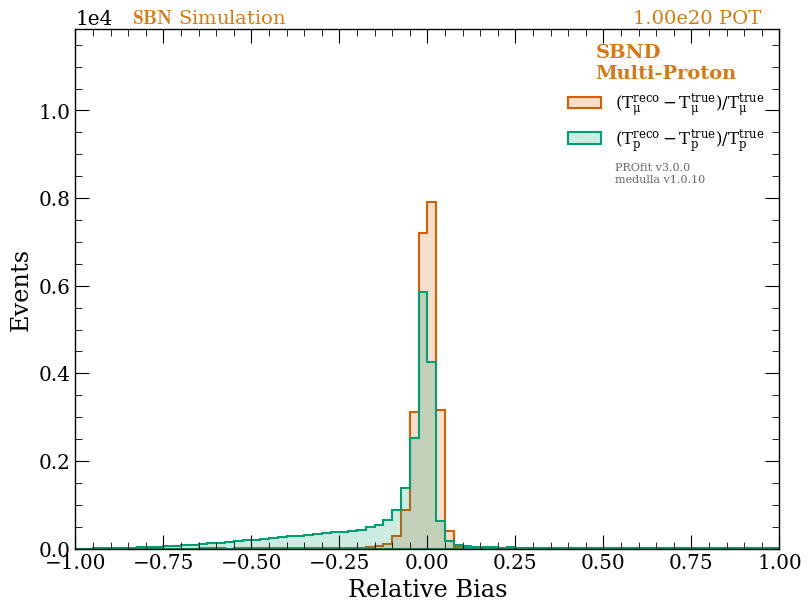

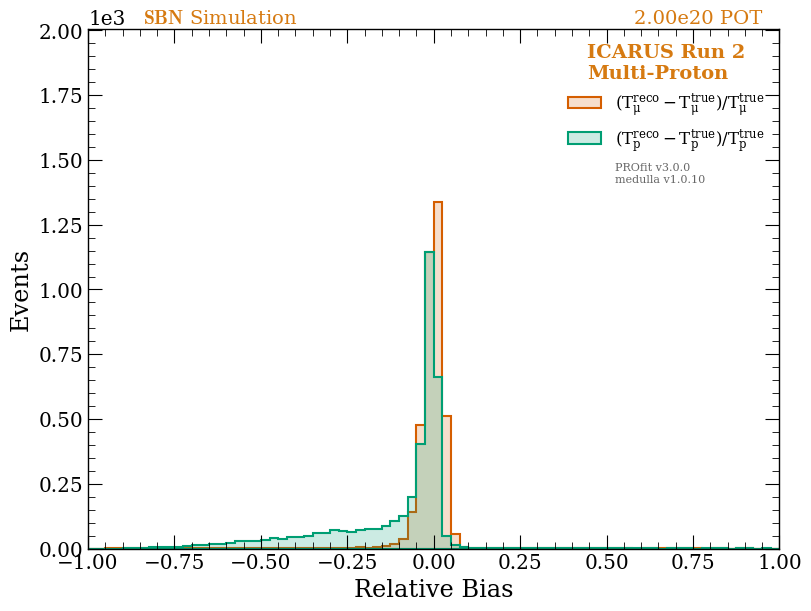

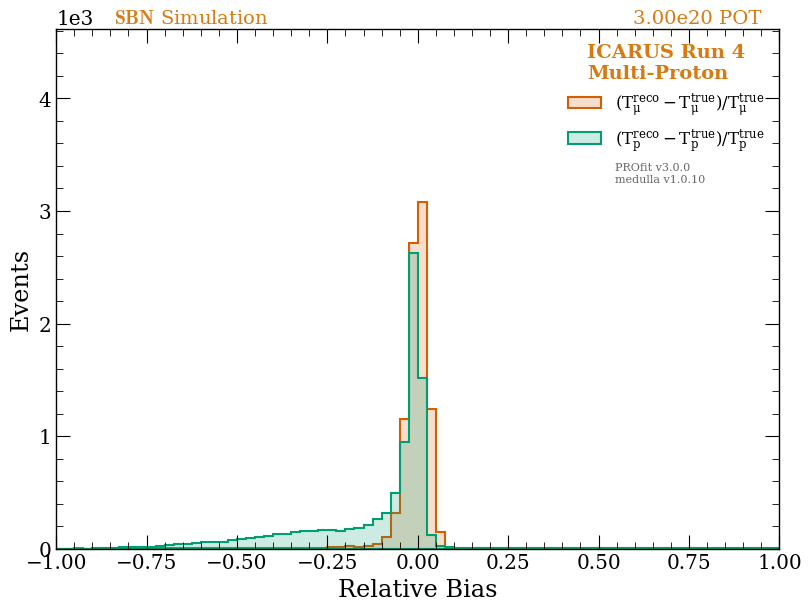

In [4]:
# Overlays, using mutools' overlay style: each entry is a step-filled histogram
# with a translucent fill, so the shapes compare directly. overlay() takes a
# list of variables paired one-to-one with a list of detectors, so repeating a
# detector index puts several variables on one axis.
#
# The variables are split into groups that share a scale: the energy biases are
# broad, while the muon and proton KE biases are far narrower and would sit as
# thin spikes beside them.
#
# It is called directly rather than through run(): the TOML path builds the
# legend labels from general['detectors'], which would repeat the detector name
# instead of naming the variables.
from mutools.plotting.profit import overlay

# Each group becomes its own overlay plot.
OVERLAY_GROUPS = {
    'energy': [4, 5, 6, 7, 10],
    'particle_ke': [8, 9],
}
OVERLAY_COLORS = {
    'energy': ['C0', 'C1', 'C2', 'C3', 'C4', 'C5'],
    'particle_ke': ['C0', 'C2'],
}

# OVERLAY_FILL = False draws outlines only, which keeps overlapping
# distributions readable; OVERLAY_FILL_ALPHA sets the fill opacity otherwise.
OVERLAY_FILL = True
OVERLAY_FILL_ALPHA = 0.2

SAVE_TO = Path('/Users/mueller/Projects/spineosc_technote/figures/signal_and_selection')
for group, group_variables in OVERLAY_GROUPS.items():
    for channel, channel_label in enumerate(channel_labels):
        # Same rule as the stacked plots: no CCQE biases in multi-proton.
        overlay_variables = [v for v in group_variables if v in set(variables_for(channel))]
        if not overlay_variables:
            continue
        for detector, detector_label in enumerate(DETECTORS):
            peak = max(
                contents.get_trace(f'{v}:0:{detector}:{channel}:total:CV', TraceType.HIST_CONTENTS)[:, 3].max()
                for v in overlay_variables
            )
            chname = 'singleproton' if channel == 0 else 'multiproton'
            detname = {0: 'sbnd', 1: 'icarus_run2', 2: 'icarus_run4'}[detector]
            overlay(
                contents,
                variable=overlay_variables,
                detectors=[detector] * len(overlay_variables),
                channel=channel,
                detector_labels=[BIAS_VARIABLES[v] for v in overlay_variables],
                channel_label=detector_label if channel_label is None else f'{detector_label}\n{channel_label}',
                xlabel='Relative Bias',
                ylabel='Events',
                xlim=[-1.0, 1.0],
                ylim=[0.0, float(HEADROOM * peak)],
                colors=OVERLAY_COLORS[group][:len(overlay_variables)],
                fill=OVERLAY_FILL,
                fill_alpha=OVERLAY_FILL_ALPHA,
                scale_by_width=False,
                code_version='v3.0.0',
                selection_version='v1.0.10',
                watermark=r'$\bf{SBN}$ Simulation',
                right_watermark=POT[detector],
                output=Path(SAVE_TO) if SAVE_TO else None,
            )
            # overlay() names its file overlay_<channel>_<variables>_<version>,
            # which carries no detector, so every detector would write the same
            # path. Rename each one straight away, before the next call
            # overwrites it -- a loop after the fact would find only the last.
            if SAVE_TO:
                auto = Path(SAVE_TO) / f"overlay_{channel}_{'-'.join(str(v) for v in overlay_variables)}_v3.0.0.{mp.saver.fmt}"
                auto.rename(Path(SAVE_TO) / f'resolution_{group}_{chname}_{detname}.{mp.saver.fmt}')
SAVE_TO = None